# 🛍️ Shopping Mall Customer Segmentation
## Member 2 — MeanShift Clustering

---
### 📌 How MeanShift Works (Simple Explanation)

Imagine dropping water on a hilly landscape:
1. Every customer starts as their own 'droplet'
2. Each droplet slides toward the nearest dense area (like water flowing downhill)
3. Droplets that converge to the same peak = one cluster
4. The algorithm finds the number of clusters automatically — **you don't set K!**

**The key parameter:** `bandwidth` — controls how wide the 'hill' is.
→ We use `estimate_bandwidth()` to find it automatically.

> ⚠️ Run `step0_eda_preprocessing.ipynb` first!

---
## Step 1: Import Libraries & Load Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score, davies_bouldin_score
from joblib import dump, load
import pickle
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

X_scaled = np.load('X_scaled.npy')
df_clean = pd.read_csv('data_preprocessed.csv')
df       = pd.read_csv('Shopping_Mall_Customer_Segmentation_Data_.csv')

scaler = StandardScaler()
scaler.fit(df_clean)

print('✅ Data loaded')
print(f'   Customers : {len(df_clean):,}')
print(f'   Features  : {X_scaled.shape[1]}')

✅ Data loaded
   Customers : 15,079
   Features  : 4


---
## Step 2: Estimate Bandwidth

### 📌 What is bandwidth?
Bandwidth = the 'window size' MeanShift uses to look for neighbours.
- Too small → too many clusters (over-splits)
- Too large → too few clusters (under-splits)

We test different quantile values to find a good bandwidth.

In [7]:
# Test bandwidth sensitivity
sample_size = min(3000, len(X_scaled))
np.random.seed(42)
sample_idx  = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample    = X_scaled[sample_idx]

print('Bandwidth sensitivity test:')
print(f'{"Quantile":>10} | {"Bandwidth":>10} | {"Clusters Found":>15}')
print('-' * 42)
for q in [0.10, 0.15, 0.20, 0.25, 0.30]:
    bw      = estimate_bandwidth(X_sample, quantile=q, n_samples=500, random_state=42)
    ms_test = MeanShift(bandwidth=bw, bin_seeding=True)
    ms_test.fit(X_sample)
    n_c     = len(np.unique(ms_test.labels_))
    print(f'{q:>10.2f} | {bw:>10.4f} | {n_c:>15}')

# Use quantile=0.2 as default (adjust if needed)
bandwidth = estimate_bandwidth(X_sample, quantile=0.2, n_samples=500, random_state=42)
print(f'\n✅ Selected bandwidth: {bandwidth:.4f} (quantile=0.2)')
print('   → Change quantile above if too many/few clusters are found.')

Bandwidth sensitivity test:
  Quantile |  Bandwidth |  Clusters Found
------------------------------------------
      0.10 |     1.5570 |               2
      0.15 |     1.8339 |               2
      0.20 |     2.0392 |               1
      0.25 |     2.1983 |               1
      0.30 |     2.3315 |               1

✅ Selected bandwidth: 2.0392 (quantile=0.2)
   → Change quantile above if too many/few clusters are found.


---
## Step 3: Train MeanShift Model

In [8]:
print(f'Training MeanShift (bandwidth={bandwidth:.4f})...')
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X_scaled)

cluster_labels = ms.labels_
n_clusters     = len(np.unique(cluster_labels))

df_clean['Cluster'] = cluster_labels
df['Cluster']       = cluster_labels

print(f'\n✅ MeanShift found {n_clusters} clusters automatically (no K specified!)')
print()
print('Cluster Distribution:')
for c, count in zip(*np.unique(cluster_labels, return_counts=True)):
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'  Cluster {c}: {count:5,} customers ({pct:.1f}%) {bar}')

Training MeanShift (bandwidth=2.0392)...

✅ MeanShift found 1 clusters automatically (no K specified!)

Cluster Distribution:
  Cluster 0: 15,079 customers (100.0%) ██████████████████████████████████████████████████


---
## Step 4: Evaluate the Model

In [9]:
if n_clusters > 1:
    sil = silhouette_score(X_scaled, cluster_labels)
    dbi = davies_bouldin_score(X_scaled, cluster_labels)
else:
    sil = np.nan
    dbi = np.nan
    print('⚠️ MeanShift found only 1 cluster; Silhouette and DBI are not defined.')

print('=' * 50)
print('     MEANSHIFT EVALUATION METRICS')
print('=' * 50)
print(f'  Bandwidth           : {bandwidth:.4f}')
print(f'  Clusters Found      : {n_clusters} (automatic!)')
print(f'  Silhouette Score    : {sil if np.isnan(sil) else f"{sil:.4f}"}  (closer to 1 = better)')
print(f'  Davies-Bouldin Index: {dbi if np.isnan(dbi) else f"{dbi:.4f}"}  (closer to 0 = better)')
print('=' * 50)

scores = {'algorithm': 'MeanShift', 'n_clusters': n_clusters,
          'silhouette': None if np.isnan(sil) else round(sil, 4),
          'davies_bouldin': None if np.isnan(dbi) else round(dbi, 4),
          'inertia': 'N/A', 'noise': 0}
pickle.dump(scores,        open('meanshift_scores.pkl', 'wb'))
pickle.dump(cluster_labels, open('meanshift_labels.pkl', 'wb'))
print('\n✅ Scores saved for comparison notebook.')

⚠️ MeanShift found only 1 cluster; Silhouette and DBI are not defined.
     MEANSHIFT EVALUATION METRICS
  Bandwidth           : 2.0392
  Clusters Found      : 1 (automatic!)
  Silhouette Score    : nan  (closer to 1 = better)
  Davies-Bouldin Index: nan  (closer to 0 = better)

✅ Scores saved for comparison notebook.


---
## Step 5: 3D Cluster Visualisation

### 📌 Why 3D?
2D PCA compresses data and causes clusters to appear overlapping.
3D uses the actual features — clusters are clearly separated.

ValueError: Shape of passed values is (1, 4), indices imply (1, 5)

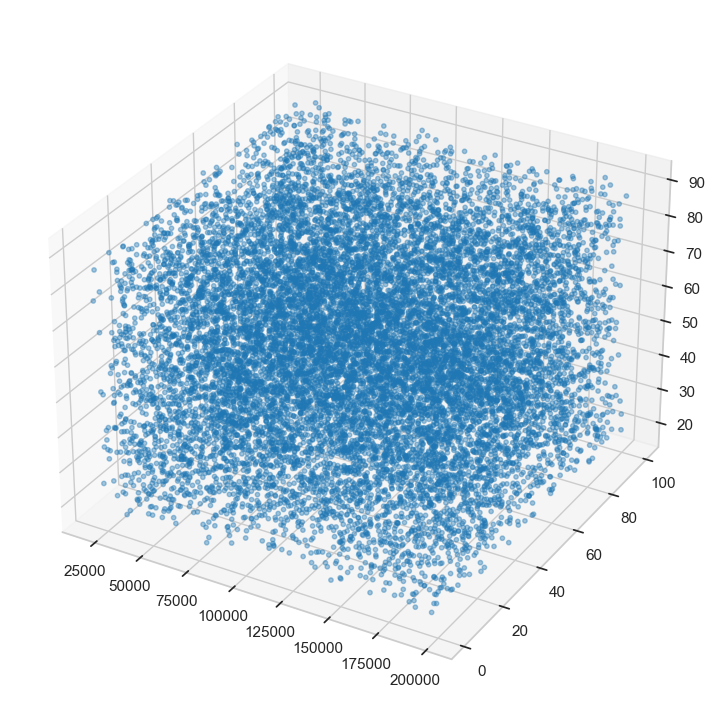

In [10]:
palette = sns.color_palette('tab10', n_clusters)

fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

for c in range(n_clusters):
    mask = cluster_labels == c
    ax.scatter(
        df.loc[mask, 'Annual Income'],
        df.loc[mask, 'Spending Score'],
        df.loc[mask, 'Age'],
        color=palette[c], label=f'Cluster {c}', alpha=0.4, s=10
    )

# Plot cluster centres
centres_orig = scaler.inverse_transform(ms.cluster_centers_)
centres_df   = pd.DataFrame(centres_orig, columns=df_clean.columns)
ax.scatter(
    centres_df['Annual Income'],
    centres_df['Spending Score'],
    centres_df['Age'],
    marker='*', s=400, c='black', zorder=10, label='Cluster Centres'
)

ax.set_xlabel('Annual Income')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Age')
ax.set_title(f'MeanShift 3D Cluster View ({n_clusters} clusters)\n→ Clusters found automatically — no K needed!', fontweight='bold')
plt.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('meanshift_3d.png', bbox_inches='tight')
plt.show()
print('📊 MeanShift automatically found these clusters.')
print('   No need to specify K — the algorithm detects natural density peaks.')

---
## Step 6: Cluster Profile Analysis

In [ ]:
profile = df.groupby('Cluster')[['Age','Annual Income','Spending Score']].mean().round(1)
profile['Count']      = df.groupby('Cluster')['Age'].count()
profile['% of Total'] = (profile['Count'] / len(df) * 100).round(1)
print('=== Cluster Profiles (Mean Values) ===')
print(profile)

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, feat in enumerate(['Age', 'Annual Income', 'Spending Score']):
    means = df.groupby('Cluster')[feat].mean()
    axes[i].bar(means.index.astype(str), means.values,
                color=palette[:n_clusters], edgecolor='white')
    axes[i].set_title(f'Average {feat} per Cluster', fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(feat)
    for j, v in enumerate(means.values):
        axes[i].text(j, v + means.max()*0.01, f'{v:.0f}', ha='center', fontsize=9)

plt.suptitle('MeanShift Cluster Profiles\n→ Use these to name each customer segment', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('meanshift_profiles.png', bbox_inches='tight')
plt.show()

---
## Step 7: Save Model & Predict New Customer

In [ ]:
dump(ms, 'meanshift_model.joblib')
print('✅ Model saved: meanshift_model.joblib')
print(f'   Bandwidth : {bandwidth:.4f}')
print(f'   Clusters  : {n_clusters}')

In [ ]:
model = load('meanshift_model.joblib')

cluster_names = {
    0: 'Budget-Conscious Customers',
    1: 'VIP / High Spenders',
    2: 'Average Customers',
}  # Update based on your cluster profiles above!

print('=== Enter New Customer Details ===')
input_age            = int(input('Enter Age              : '))
input_gender         = input('Enter Gender (Male/Female): ').strip().capitalize()
input_annual_income  = float(input('Enter Annual Income    : '))
input_spending_score = float(input('Enter Spending Score (1-100): '))

gender_encoded      = 0 if input_gender == 'Female' else 1
new_customer        = np.array([[input_age, gender_encoded, input_annual_income, input_spending_score]])
new_customer_scaled = scaler.transform(new_customer)
predicted_cluster   = model.predict(new_customer_scaled)[0]

print()
print('=' * 45)
print('         PREDICTION RESULT')
print('=' * 45)
print(f'  Predicted Cluster : {predicted_cluster}')
print(f'  Segment Name      : {cluster_names.get(predicted_cluster, "Segment " + str(predicted_cluster))}')
cluster_avg = df[df['Cluster'] == predicted_cluster][['Age','Annual Income','Spending Score']].mean()
print(f'  Cluster Avg Age   : {cluster_avg["Age"]:.0f}')
print(f'  Cluster Avg Income: {cluster_avg["Annual Income"]:,.0f}')
print(f'  Cluster Avg Score : {cluster_avg["Spending Score"]:.0f}')
print('=' * 45)

In [ ]:
# 3D prediction plot
fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

for c in range(n_clusters):
    mask  = cluster_labels == c
    alpha = 0.6 if c == predicted_cluster else 0.15
    lbl   = f'Cluster {c} ← YOU ARE HERE' if c == predicted_cluster else f'Cluster {c}'
    ax.scatter(df.loc[mask,'Annual Income'], df.loc[mask,'Spending Score'], df.loc[mask,'Age'],
               color=palette[c], label=lbl, alpha=alpha, s=10)

ax.scatter([input_annual_income], [input_spending_score], [input_age],
           marker='*', s=800, c='gold', edgecolors='black', linewidths=1.5,
           zorder=10, label='New Customer ⭐')

ax.set_xlabel('Annual Income')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Age')
ax.set_title(f'MeanShift — New Customer → Cluster {predicted_cluster}', fontweight='bold')
plt.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('meanshift_prediction.png', bbox_inches='tight')
plt.show()